In [1]:
!pip install --upgrade scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
# This gives Colab access to files stored in your Google Drive,
# so we can load the dataset and later save models/scalers there.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================
# STEP 2: Import Required Libraries
# ============================================

# For data handling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# For saving models
import joblib
import os

# Ignore harmless warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Search for the file anywhere in your Drive
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-iname', '*cervical*'],
                         capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/Colab Notebooks/Cervical_Cancer_ML_Project.ipynb
/content/drive/MyDrive/Machine Learning Projects/merged_cervical_cancer.csv
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_feature_info.csv
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_gradient_boosting.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_adaboost.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_logistic_regression.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_svm.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_naive_bayes.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_knn.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_scaler.pkl
/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1/cervical_deci

In [5]:
# ============================================
# STEP 3: Load Dataset from Google Drive
# ============================================

file_path = '/content/drive/MyDrive/Machine Learning Projects/merged_cervical_cancer.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (1670, 36)


In [6]:
# ============================================
# STEP 4: Initial Dataset Inspection
# ============================================

# 1. Shape of the dataset (rows, columns)
print("Dataset Shape:", df.shape)

# 2. First 5 rows
print("\nFirst 5 Rows:")
df.head()
# 3. Dataset information (column names, data types, non-null counts)
print("Dataset Info:")
df.info()
# 4. Missing values per column
print("Missing Values per Column:")
df.isnull().sum().sort_values(ascending=False)


Dataset Shape: (1670, 36)

First 5 Rows:
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 0 to 1669
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 1670 non-null   int64  
 1   Number of sexual partners           1620 non-null   float64
 2   First sexual intercourse            1656 non-null   float64
 3   Num of pregnancies                  1558 non-null   float64
 4   Smokes                              1644 non-null   float64
 5   Smokes (years)                      1644 non-null   float64
 6   Smokes (packs/year)                 1644 non-null   float64
 7   Hormonal Contraceptives             1464 non-null   float64
 8   Hormonal Contraceptives (years)     1464 non-null   float64
 9   IUD                                 1446 non-null   float64
 10  IUD (years)                         1446 non-null   f

,0
STDs: Time since first diagnosis,1528
STDs: Time since last diagnosis,1528
IUD,224
IUD (years),224
Hormonal Contraceptives,206
Hormonal Contraceptives (years),206
STDs:HPV,200
STDs:AIDS,200
STDs:Hepatitis B,200
STDs:HIV,200


In [7]:
# ============================================
# Drop columns that leak the diagnosis (target leakage)
# ============================================
# Hinselmann, Schiller, Citology = other diagnostic tests (same purpose as Biopsy)
# Dx, Dx:Cancer, Dx:CIN, Dx:HPV = prior diagnosis flags
# Keeping these would let the model "cheat" instead of learning real risk factors,
# and they wouldn't be available as real-world Streamlit inputs anyway.

leakage_cols = ['Hinselmann', 'Schiller', 'Citology', 'Dx', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV']
df = df.drop(columns=leakage_cols)

print("Leakage columns dropped.")
print(f"New shape: {df.shape}")

Leakage columns dropped.
New shape: (1670, 29)


Biopsy Value Counts:
Biopsy
0    1562
1     108
Name: count, dtype: int64

Biopsy Class Percentage:
Biopsy
0    93.532934
1     6.467066
Name: proportion, dtype: float64


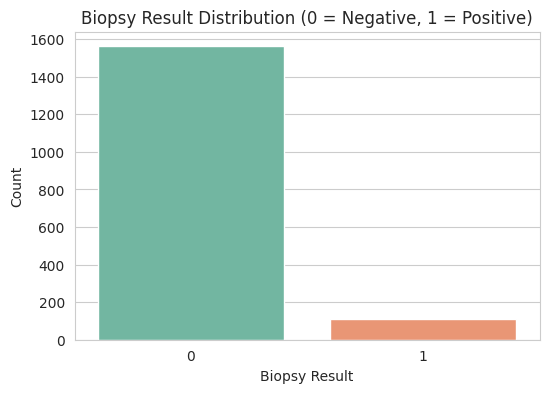

In [8]:
# ============================================
# STEP 5.1: Target Class Distribution
# ============================================
# This tells us how imbalanced our target (Biopsy) is —
# critical for choosing the right evaluation metrics later.

print("Biopsy Value Counts:")
print(df['Biopsy'].value_counts())
print("\nBiopsy Class Percentage:")
print(df['Biopsy'].value_counts(normalize=True) * 100)

# Visualize it
plt.figure(figsize=(6, 4))
sns.countplot(x='Biopsy', data=df, palette='Set2')
plt.title('Biopsy Result Distribution (0 = Negative, 1 = Positive)')
plt.xlabel('Biopsy Result')
plt.ylabel('Count')
plt.show()

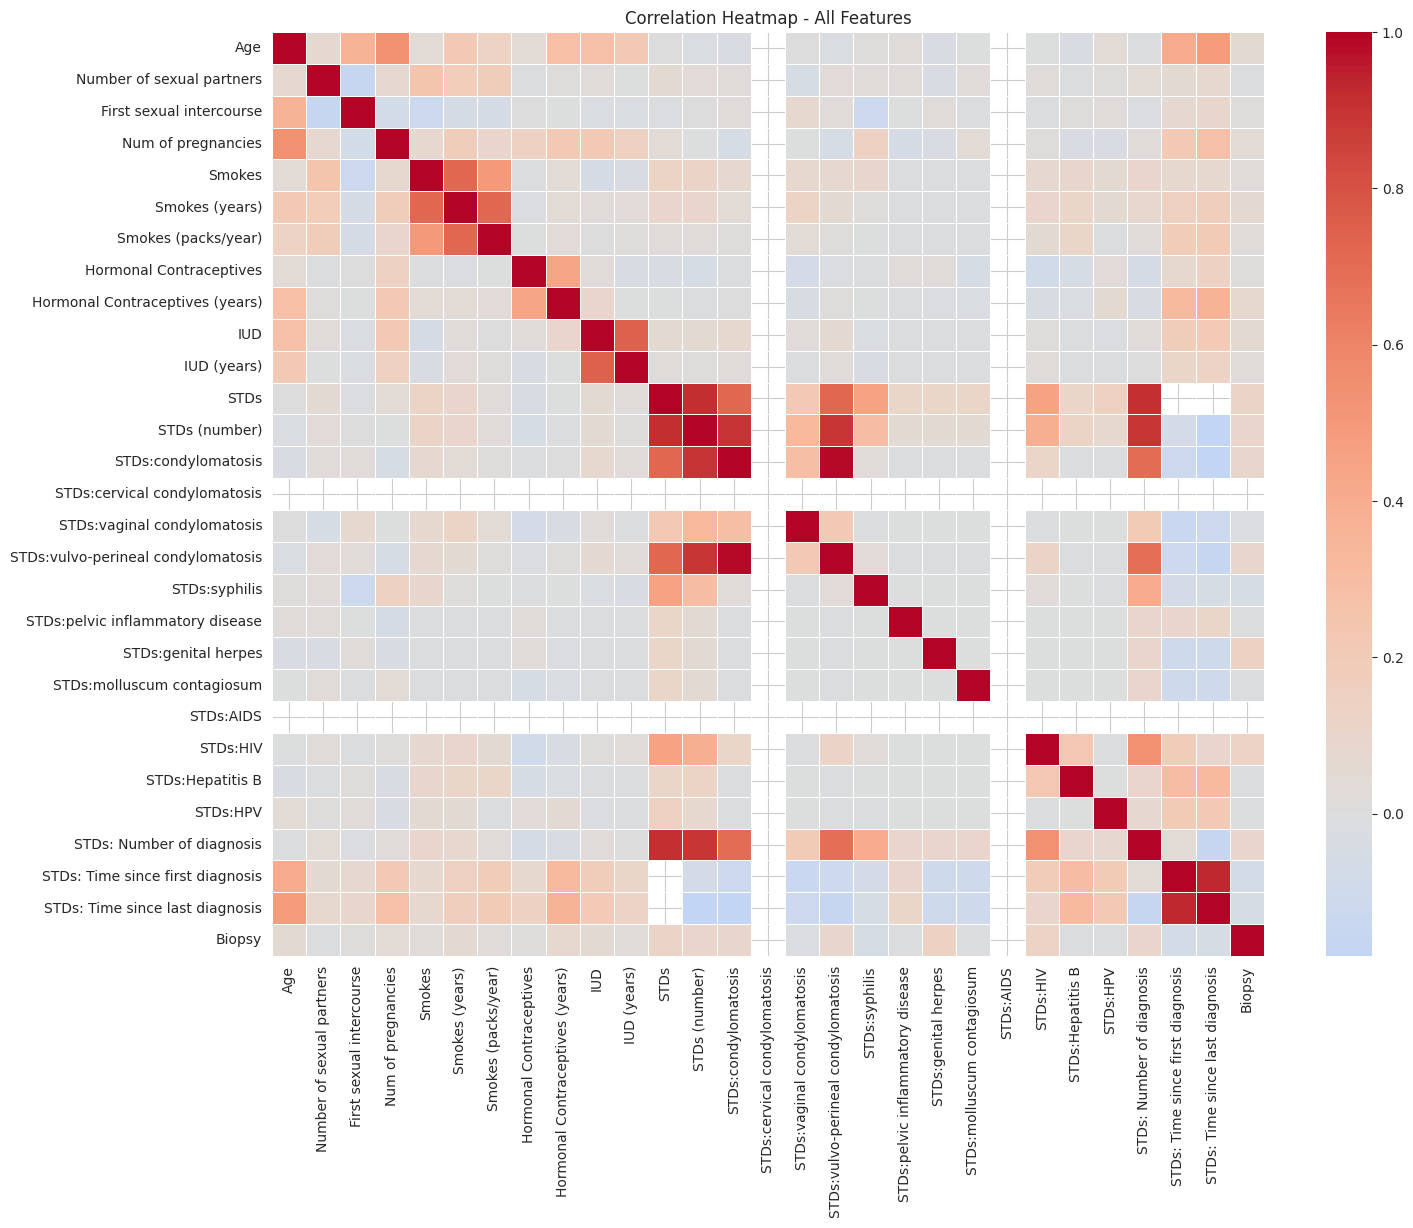

Top features correlated with Biopsy:
Biopsy                                1.000000
STDs:genital herpes                   0.133771
STDs:HIV                              0.127933
STDs                                  0.109832
STDs (number)                         0.098977
STDs: Number of diagnosis             0.097813
STDs:vulvo-perineal condylomatosis    0.089484
STDs:condylomatosis                   0.086943
Hormonal Contraceptives (years)       0.080128
Smokes (years)                        0.062019
Name: Biopsy, dtype: float64


In [9]:
# ============================================
# STEP 5.2: Correlation Heatmap
# ============================================
# Shows how numeric features relate to each other and to Biopsy.
# Helps spot multicollinearity and features most linked to the target.

plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - All Features')
plt.show()

# Also print the top features most correlated with Biopsy specifically
print("Top features correlated with Biopsy:")
print(corr_matrix['Biopsy'].sort_values(ascending=False).head(10))

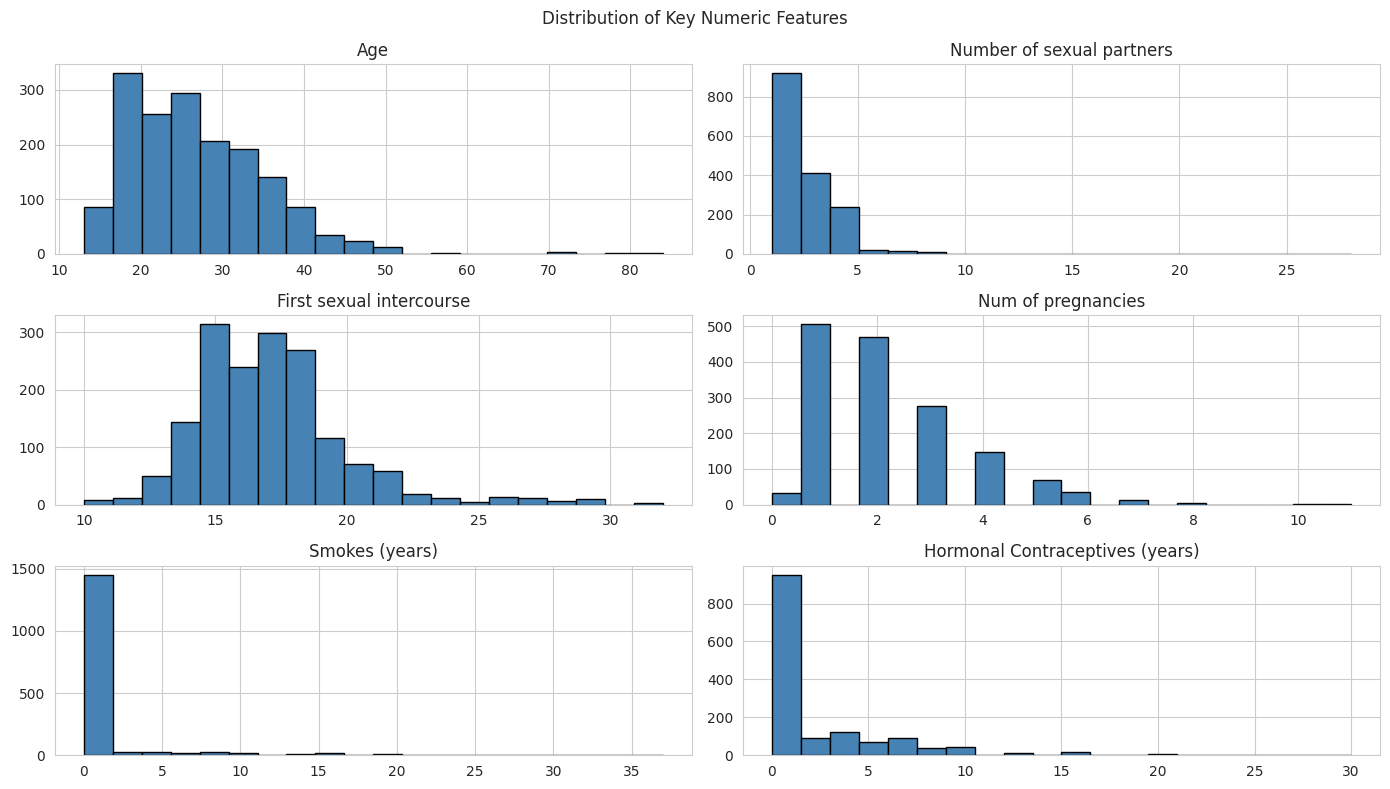

In [10]:
# ============================================
# STEP 5.3: Histograms of Key Numeric Features
# ============================================
# Shows the distribution/spread of important numeric features.

numeric_features = ['Age', 'Number of sexual partners', 'First sexual intercourse',
                     'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)']

df[numeric_features].hist(figsize=(14, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Numeric Features')
plt.tight_layout()
plt.show()

In [11]:
# ============================================
# STEP 5.4: Outlier Detection (IQR method, text-based)
# ============================================
# Instead of boxplot images, we calculate outlier boundaries and counts directly.

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

Age: 22 outliers (bounds: 4.50 to 48.50)
Number of sexual partners: 136 outliers (bounds: 0.50 to 4.50)
First sexual intercourse: 82 outliers (bounds: 10.50 to 22.50)
Num of pregnancies: 20 outliers (bounds: -2.00 to 6.00)
Smokes (years): 246 outliers (bounds: 0.00 to 0.00)
Hormonal Contraceptives (years): 136 outliers (bounds: -4.50 to 7.50)


In [12]:
# ============================================
# STEP 5.5: Feature Comparison by Target Class
# ============================================
# Compares average feature values between Biopsy-positive and Biopsy-negative patients

comparison_features = ['Age', 'Number of sexual partners', 'STDs (number)',
                        'STDs: Number of diagnosis', 'Smokes (years)']

df.groupby('Biopsy')[comparison_features].mean()

,Age,Number of sexual partners,STDs (number),STDs: Number of diagnosis,Smokes (years)
Biopsy,,,,,
0,26.902689,2.556143,0.165447,0.081946,1.186473
1,28.777778,2.490566,0.384615,0.203704,2.231452


In [13]:
# ============================================
# STEP 6.1: Check for Duplicate Rows
# ============================================
# The dataset description says duplicates were already removed during
# preparation, but let's verify that ourselves.

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 838


In [14]:
# ============================================
# STEP 6.2: Investigate the duplicates before deciding
# ============================================
# Check how many of the duplicate rows are Biopsy-positive —
# this tells us if removing them would hurt our already-small minority class

duplicate_rows = df[df.duplicated(keep=False)]
print("Biopsy distribution among duplicate rows:")
print(duplicate_rows['Biopsy'].value_counts())

print("\nBiopsy distribution in full dataset (for comparison):")
print(df['Biopsy'].value_counts())

Biopsy distribution among duplicate rows:
Biopsy
0    1562
1     108
Name: count, dtype: int64

Biopsy distribution in full dataset (for comparison):
Biopsy
0    1562
1     108
Name: count, dtype: int64


In [15]:
# ============================================
# STEP 6.3: Handle Missing Values
# ============================================
# Strategy: median imputation for all numeric features (robust to skew/outliers,
# as we saw in EDA). We do NOT drop rows, since we can't afford to lose any
# of our 108 positive cases.

# First, drop the two columns that are ~91% missing (too sparse to impute meaningfully)
df = df.drop(columns=['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'])

# Impute all remaining missing values with the median of each column
df = df.fillna(df.median(numeric_only=True))

# Verify no missing values remain
print("Remaining missing values:")
print(df.isnull().sum().sum())
print(f"\nDataset shape after cleaning: {df.shape}")

Remaining missing values:
0

Dataset shape after cleaning: (1670, 27)


In [16]:
# ============================================
# STEP 7.1: Check individual STD columns - variance & correlation with summary column
# ============================================

std_individual_cols = ['STDs:condylomatosis', 'STDs:cervical condylomatosis',
                        'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis',
                        'STDs:syphilis', 'STDs:pelvic inflammatory disease',
                        'STDs:genital herpes', 'STDs:molluscum contagiosum',
                        'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV']

# How often each STD type actually occurs (value = 1)
print("Occurrence count for each STD type:")
print(df[std_individual_cols].sum().sort_values(ascending=False))

Occurrence count for each STD type:
STDs:condylomatosis                   88.0
STDs:vulvo-perineal condylomatosis    86.0
STDs:HIV                              36.0
STDs:syphilis                         36.0
STDs:vaginal condylomatosis            8.0
STDs:HPV                               4.0
STDs:molluscum contagiosum             2.0
STDs:pelvic inflammatory disease       2.0
STDs:Hepatitis B                       2.0
STDs:genital herpes                    2.0
STDs:cervical condylomatosis           0.0
STDs:AIDS                              0.0
dtype: float64


In [17]:
# ============================================
# STEP 7.2: Drop Zero/Near-Zero Variance STD Columns
# ============================================
# These columns have too few (or zero) occurrences to provide any
# reliable learnable signal. We retain the general STD signal through
# 'STDs (number)' and 'STDs: Number of diagnosis' instead.

low_variance_std_cols = [
    'STDs:cervical condylomatosis',      # 0 occurrences
    'STDs:AIDS',                          # 0 occurrences
    'STDs:molluscum contagiosum',         # 2 occurrences
    'STDs:pelvic inflammatory disease',   # 2 occurrences
    'STDs:Hepatitis B',                   # 2 occurrences
    'STDs:genital herpes'                 # 2 occurrences
]

df = df.drop(columns=low_variance_std_cols)

print("Low-variance STD columns dropped.")
print(f"New shape: {df.shape}")

Low-variance STD columns dropped.
New shape: (1670, 21)


In [18]:
# ============================================
# STEP 7.3: Check Smoking Columns for Redundancy
# ============================================
# We have 3 smoking-related columns: Smokes (binary), Smokes (years),
# Smokes (packs/year). Let's check how they relate to decide if we
# need all three or can simplify.

print("Correlation between smoking columns:")
print(df[['Smokes', 'Smokes (years)', 'Smokes (packs/year)']].corr())

print("\nHow many smokers (Smokes=1) vs non-smokers (Smokes=0):")
print(df['Smokes'].value_counts())

Correlation between smoking columns:
                       Smokes  Smokes (years)  Smokes (packs/year)
Smokes               1.000000        0.722775             0.492980
Smokes (years)       0.722775        1.000000             0.723954
Smokes (packs/year)  0.492980        0.723954             1.000000

How many smokers (Smokes=1) vs non-smokers (Smokes=0):
Smokes
0.0    1424
1.0     246
Name: count, dtype: int64


In [19]:
# ============================================
# STEP 7.3: Drop Redundant Binary 'Smokes' Column
# ============================================
# 'Smokes (years)' already implies smoking status (0 years = non-smoker),
# making the binary 'Smokes' flag redundant.

df = df.drop(columns=['Smokes'])

print("'Smokes' column dropped.")
print(f"New shape: {df.shape}")

'Smokes' column dropped.
New shape: (1670, 20)


In [20]:
# ============================================
# STEP 8.1: Check for Non-Numeric Columns
# ============================================

print("Data types of all columns:")
print(df.dtypes.value_counts())

print("\nAny object (text/categorical) columns?")
print(df.select_dtypes(include='object').columns.tolist())

Data types of all columns:
float64    17
int64       3
Name: count, dtype: int64

Any object (text/categorical) columns?
[]


In [21]:
# ============================================
# STEP 8.2: Confirm No Encoding Needed
# ============================================
# All features are already numeric (binary flags as 0/1, or continuous values).
# No categorical text columns exist, so Label/One-Hot Encoding is not required.

print("Encoding step skipped — all features are already numeric.")
print(df.dtypes)

Encoding step skipped — all features are already numeric.
Age                                     int64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               float64
Hormonal Contraceptives (years)       float64
IUD                                   float64
IUD (years)                           float64
STDs                                  float64
STDs (number)                         float64
STDs:condylomatosis                   float64
STDs:vaginal condylomatosis           float64
STDs:vulvo-perineal condylomatosis    float64
STDs:syphilis                         float64
STDs:HIV                              float64
STDs:HPV                              float64
STDs: Number of diagnosis               int64
Biopsy                                  int64
dtype: object


In [22]:
# ============================================
# STEP 9.1: Check Correlation Among STD-Related Columns
# ============================================
# We kept both individual STD flags AND summary columns —
# let's check how redundant they are with each other.

std_related = ['STDs', 'STDs (number)', 'STDs: Number of diagnosis',
                'STDs:condylomatosis', 'STDs:vaginal condylomatosis',
                'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
                'STDs:HIV', 'STDs:HPV']

print(df[std_related].corr().round(2))

                                    STDs  STDs (number)  \
STDs                                1.00           0.92   
STDs (number)                       0.92           1.00   
STDs: Number of diagnosis           0.91           0.90   
STDs:condylomatosis                 0.73           0.90   
STDs:vaginal condylomatosis         0.21           0.34   
STDs:vulvo-perineal condylomatosis  0.72           0.89   
STDs:syphilis                       0.46           0.31   
STDs:HIV                            0.46           0.39   
STDs:HPV                            0.15           0.08   

                                    STDs: Number of diagnosis  \
STDs                                                     0.91   
STDs (number)                                            0.90   
STDs: Number of diagnosis                                1.00   
STDs:condylomatosis                                      0.70   
STDs:vaginal condylomatosis                              0.21   
STDs:vulvo-perineal

In [23]:
# ============================================
# STEP 9.2: Drop Redundant STD-Related Columns
# ============================================
# Dropping columns that are near-duplicates of ones we're keeping:
# - 'STDs' and 'STDs: Number of diagnosis' are highly correlated (0.90-0.92)
#   with 'STDs (number)', which we keep as the single summary measure.
# - 'STDs:vulvo-perineal condylomatosis' is 0.99 correlated with
#   'STDs:condylomatosis', which we keep instead.

redundant_std_cols = ['STDs', 'STDs: Number of diagnosis', 'STDs:vulvo-perineal condylomatosis']
df = df.drop(columns=redundant_std_cols)

print("Redundant STD columns dropped.")
print(f"New shape: {df.shape}")
print(f"\nRemaining columns:\n{df.columns.tolist()}")

Redundant STD columns dropped.
New shape: (1670, 17)

Remaining columns:
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:syphilis', 'STDs:HIV', 'STDs:HPV', 'Biopsy']


In [24]:
# ============================================
# STEP 10: Split Dataset into X (features) and y (target)
# ============================================

X = df.drop(columns=['Biopsy'])
y = df['Biopsy']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

X shape: (1670, 16)
y shape: (1670,)

Feature columns: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:syphilis', 'STDs:HIV', 'STDs:HPV']


In [25]:
# ============================================
# STEP 11: Train-Test Split (Stratified)
# ============================================
# stratify=y ensures both train and test sets keep the same
# Biopsy class ratio (93.5% negative / 6.5% positive) as the full dataset.
# test_size=0.2 -> 80% train, 20% test
# random_state=42 -> reproducible split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nBiopsy distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nBiopsy distribution in y_test:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (1336, 16)
X_test shape: (334, 16)

Biopsy distribution in y_train:
Biopsy
0    93.562874
1     6.437126
Name: proportion, dtype: float64

Biopsy distribution in y_test:
Biopsy
0    93.413174
1     6.586826
Name: proportion, dtype: float64


In [26]:
# ============================================
# STEP 12: Feature Scaling
# ============================================
# RobustScaler is used instead of StandardScaler because several features
# (Age, Number of sexual partners, Smokes years, etc.) are skewed with
# genuine outliers we chose to keep — RobustScaler uses median/IQR,
# making it less sensitive to those extreme values.

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# Fit ONLY on training data (avoid data leakage from test set)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler (already fit on train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Feature scaling complete.
X_train_scaled shape: (1336, 16)
X_test_scaled shape: (334, 16)


In [27]:
# ============================================
# STEP 13.1: Initialize All 8 Baseline Models
# ============================================
# class_weight='balanced' is used wherever supported, so each model
# accounts for our severe class imbalance (93.5% / 6.5%) automatically.

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),  # KNN has no class_weight parameter
    'Naive Bayes': GaussianNB(),    # Naive Bayes has no class_weight parameter
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),  # no class_weight support
    'AdaBoost': AdaBoostClassifier(random_state=42)  # no class_weight support
}

print(f"Initialized {len(models)} models:")
for name in models:
    print(f"  - {name}")

Initialized 8 models:
  - Logistic Regression
  - KNN
  - Naive Bayes
  - Decision Tree
  - Random Forest
  - SVM
  - Gradient Boosting
  - AdaBoost


In [28]:
# ============================================
# STEP 13.2: Train and Evaluate All Baseline Models
# ============================================
# Trains each model on scaled training data, predicts on test data,
# and records key metrics for comparison. Given our imbalance,
# we prioritize F1/Recall/ROC-AUC over raw Accuracy.

baseline_results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    baseline_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"{name} trained and evaluated.")

# Convert to DataFrame for easy viewing
baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Baseline Model Results (Before Tuning) ===")
baseline_df

Logistic Regression trained and evaluated.
KNN trained and evaluated.
Naive Bayes trained and evaluated.
Decision Tree trained and evaluated.
Random Forest trained and evaluated.
SVM trained and evaluated.
Gradient Boosting trained and evaluated.
AdaBoost trained and evaluated.

=== Baseline Model Results (Before Tuning) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Random Forest,0.985030,0.869565,0.909091,0.888889,0.993590
3,Decision Tree,0.976048,0.733333,1.000000,0.846154,0.986597
6,Gradient Boosting,0.958084,1.000000,0.363636,0.533333,0.945659
5,SVM,0.883234,0.319149,0.681818,0.434783,0.787005
0,Logistic Regression,0.784431,0.171053,0.590909,0.265306,0.747378
1,KNN,0.937126,0.666667,0.090909,0.160000,0.871941
2,Naive Bayes,0.092814,0.067692,1.000000,0.126801,0.747523
7,AdaBoost,0.934132,0.000000,0.000000,0.000000,0.802666


In [29]:
# ============================================
# STEP 14.1: Define Hyperparameter Grids for Each Model
# ============================================
# Small, sensible search spaces chosen for fast tuning on our dataset size (1336 train rows).
# scoring='f1' is used in GridSearchCV since F1 is our priority metric given the imbalance.

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

print("Hyperparameter grids defined for all 8 models.")

Hyperparameter grids defined for all 8 models.


In [30]:
# ============================================
# STEP 14.2: Hyperparameter Tuning with GridSearchCV
# ============================================
# For each model, GridSearchCV searches the parameter grid using
# 5-fold stratified cross-validation, optimizing for F1-score
# (our priority metric given the class imbalance).

from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_models = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    # Store the best version of this model
    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    # Evaluate on test set
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    tuned_results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"  Done. Best F1 (CV): {grid_search.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Tuned Model Results (After Tuning) ===")
tuned_df

Tuning Logistic Regression...
  Done. Best F1 (CV): 0.1506
Tuning KNN...
  Done. Best F1 (CV): 0.7268
Tuning Naive Bayes...
  Done. Best F1 (CV): 0.1247
Tuning Decision Tree...
  Done. Best F1 (CV): 0.6635
Tuning Random Forest...
  Done. Best F1 (CV): 0.7372
Tuning SVM...
  Done. Best F1 (CV): 0.2696
Tuning Gradient Boosting...
  Done. Best F1 (CV): 0.7085
Tuning AdaBoost...
  Done. Best F1 (CV): 0.0000

=== Tuned Model Results (After Tuning) ===


,Model,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,KNN,"{'n_neighbors': 11, 'weights': 'distance'}",0.991018,1.000000,0.863636,0.926829,0.951049
6,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...",0.991018,1.000000,0.863636,0.926829,0.936480
4,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.982036,0.833333,0.909091,0.869565,0.991259
3,Decision Tree,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.976048,0.733333,1.000000,0.846154,0.986597
5,SVM,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.841317,0.268657,0.818182,0.404494,0.846737
0,Logistic Regression,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.796407,0.180556,0.590909,0.276596,0.746941
2,Naive Bayes,{'var_smoothing': 1e-09},0.092814,0.067692,1.000000,0.126801,0.747523
7,AdaBoost,"{'learning_rate': 0.01, 'n_estimators': 50}",0.934132,0.000000,0.000000,0.000000,0.535839


In [31]:
# ============================================
# STEP 15.1: Build Before vs After Comparison Table
# ============================================
# For SVM specifically, we keep the BASELINE version since tuning made it
# worse (0.435 -> 0.404 F1) — per project requirement, we don't force a
# worse tuned model just because tuning was performed.

comparison_df = pd.DataFrame({
    'Model': baseline_df['Model'].values,
})

# Merge baseline and tuned F1/Accuracy side by side for direct comparison
comparison_df = baseline_df[['Model', 'Accuracy', 'F1-Score']].merge(
    tuned_df[['Model', 'Accuracy', 'F1-Score']],
    on='Model',
    suffixes=(' (Before)', ' (After)')
)

# Add a column showing F1 improvement (or decline)
comparison_df['F1 Change'] = comparison_df['F1-Score (After)'] - comparison_df['F1-Score (Before)']

# Flag models where tuning made things worse
comparison_df['Tuning Helped?'] = comparison_df['F1 Change'].apply(
    lambda x: 'Yes' if x > 0 else ('No Change' if x == 0 else 'No - Worse!')
)

comparison_df = comparison_df.sort_values(by='F1-Score (After)', ascending=False)
print("=== Before vs After Tuning Comparison ===")
comparison_df

=== Before vs After Tuning Comparison ===


,Model,Accuracy (Before),F1-Score (Before),Accuracy (After),F1-Score (After),F1 Change,Tuning Helped?
2,Gradient Boosting,0.958084,0.533333,0.991018,0.926829,0.393496,Yes
5,KNN,0.937126,0.160000,0.991018,0.926829,0.766829,Yes
0,Random Forest,0.985030,0.888889,0.982036,0.869565,-0.019324,No - Worse!
1,Decision Tree,0.976048,0.846154,0.976048,0.846154,0.000000,No Change
3,SVM,0.883234,0.434783,0.841317,0.404494,-0.030288,No - Worse!
4,Logistic Regression,0.784431,0.265306,0.796407,0.276596,0.011290,Yes
6,Naive Bayes,0.092814,0.126801,0.092814,0.126801,0.000000,No Change
7,AdaBoost,0.934132,0.000000,0.934132,0.000000,0.000000,No Change


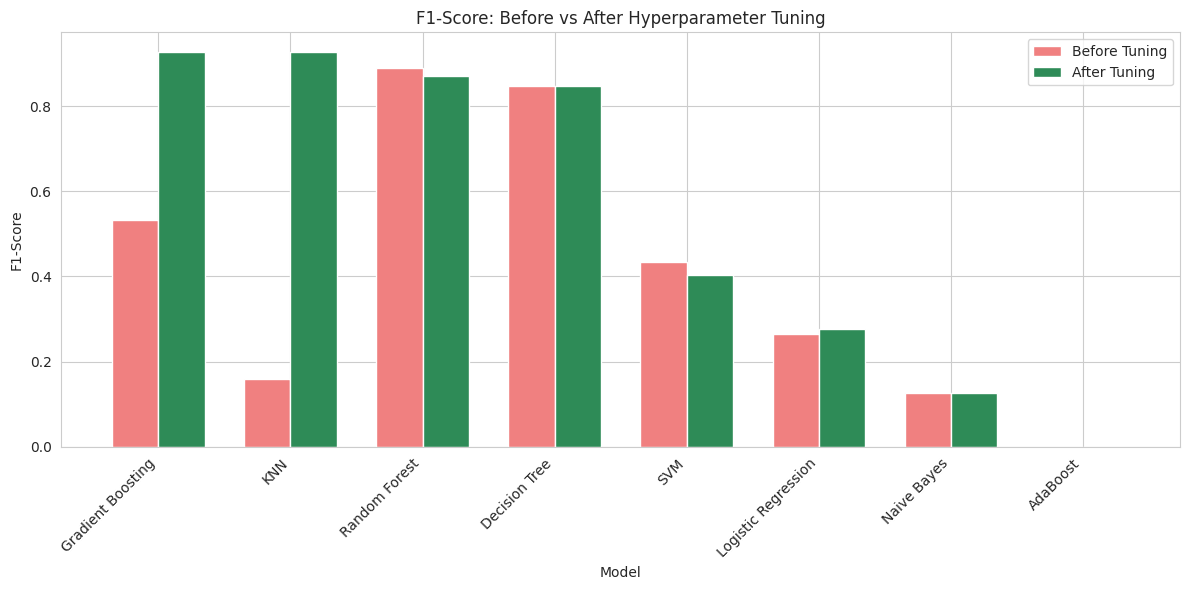

Chart saved as before_after_tuning_f1.png


In [32]:
# ============================================
# STEP 15.2: Visualize Before vs After Tuning (F1-Score)
# ============================================

plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['F1-Score (Before)'], width, label='Before Tuning', color='lightcoral')
plt.bar(x + width/2, comparison_df['F1-Score (After)'], width, label='After Tuning', color='seagreen')

plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('F1-Score: Before vs After Hyperparameter Tuning')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('before_after_tuning_f1.png', dpi=150)
plt.show()

print("Chart saved as before_after_tuning_f1.png")

In [33]:
# ============================================
# STEP 16.1: Build Final Model Dictionary
# ============================================
# Use TUNED versions for all models except SVM, where we keep the
# BASELINE version since tuning made it perform worse.

final_models = tuned_models.copy()

# Retrain baseline SVM (original untuned settings) and use it instead of tuned SVM
final_svm = SVC(class_weight='balanced', probability=True, random_state=42)
final_svm.fit(X_train_scaled, y_train)
final_models['SVM'] = final_svm

print("Final model set assembled (SVM reverted to baseline version):")
for name in final_models:
    print(f"  - {name}")

Final model set assembled (SVM reverted to baseline version):
  - Logistic Regression
  - KNN
  - Naive Bayes
  - Decision Tree
  - Random Forest
  - SVM
  - Gradient Boosting
  - AdaBoost


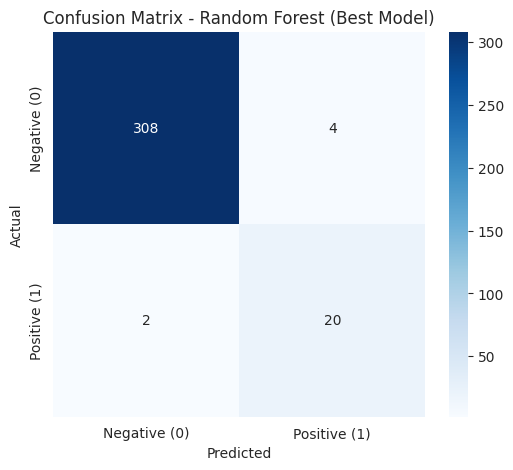

Confusion Matrix:
[[308   4]
 [  2  20]]

True Negatives: 308, False Positives: 4
False Negatives: 2, True Positives: 20


In [34]:
# ============================================
# STEP 16.2: Confusion Matrix for Best Model (Random Forest)
# ============================================

best_model = final_models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Random Forest (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix_random_forest.png', dpi=150)
plt.show()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0][0]}, False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}, True Positives: {cm[1][1]}")

In [35]:
# ============================================
# STEP 17.1: Create Directory Structure for Saved Models
# ============================================
# Saving both locally (in Colab) and to Drive, so it's easy to pull
# into Streamlit later without re-running the whole notebook.

import os

local_dir = 'saved_models/notebook1'
drive_dir = '/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1'

os.makedirs(local_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)

print(f"Local directory ready: {local_dir}")
print(f"Drive directory ready: {drive_dir}")

Local directory ready: saved_models/notebook1
Drive directory ready: /content/drive/MyDrive/Machine Learning Projects/saved_models/notebook1


In [36]:
# ============================================
# STEP 17.2: Save All Final Models and Scaler (joblib)
# ============================================
# Meaningful filenames based on the dataset ('cervical') and model name.
# Saved to BOTH local Colab storage and Google Drive.

# Save each final model (SVM is the baseline version, all others are tuned)
for name, model in final_models.items():
    filename = 'cervical_' + name.lower().replace(' ', '_') + '.pkl'

    local_path = os.path.join(local_dir, filename)
    drive_path = os.path.join(drive_dir, filename)

    joblib.dump(model, local_path)
    joblib.dump(model, drive_path)

    print(f"Saved: {filename}")

# Save the scaler too (needed to transform new user inputs in Streamlit)
scaler_filename = 'cervical_scaler.pkl'
joblib.dump(scaler, os.path.join(local_dir, scaler_filename))
joblib.dump(scaler, os.path.join(drive_dir, scaler_filename))
print(f"Saved: {scaler_filename}")

print("\nAll models and scaler saved successfully to both local and Drive locations.")

Saved: cervical_logistic_regression.pkl
Saved: cervical_knn.pkl
Saved: cervical_naive_bayes.pkl
Saved: cervical_decision_tree.pkl
Saved: cervical_random_forest.pkl
Saved: cervical_svm.pkl
Saved: cervical_gradient_boosting.pkl
Saved: cervical_adaboost.pkl
Saved: cervical_scaler.pkl

All models and scaler saved successfully to both local and Drive locations.


In [37]:
# ============================================
# STEP 18: Save Feature Metadata for Streamlit
# ============================================
# Records each feature's name, data range, and type — so building the
# Streamlit input form later doesn't require re-deriving this from scratch.

feature_info = X.describe().T[['min', 'max', 'mean']]
feature_info['dtype'] = X.dtypes.values
print("Feature Info (for Streamlit input form reference):")
print(feature_info)

# Save this reference table too, so it's available without rerunning the notebook
feature_info.to_csv(os.path.join(local_dir, 'cervical_feature_info.csv'))
feature_info.to_csv(os.path.join(drive_dir, 'cervical_feature_info.csv'))
print("\nFeature info saved as cervical_feature_info.csv")

Feature Info (for Streamlit input form reference):
                                  min   max       mean    dtype
Age                              13.0  84.0  27.023952    int64
Number of sexual partners         1.0  28.0   2.535329  float64
First sexual intercourse         10.0  32.0  17.020359  float64
Num of pregnancies                0.0  11.0   2.283832  float64
Smokes (years)                    0.0  37.0   1.234329  float64
Smokes (packs/year)               0.0  37.0   0.458571  float64
Hormonal Contraceptives           0.0   1.0   0.694611  float64
Hormonal Contraceptives (years)   0.0  30.0   2.080520  float64
IUD                               0.0   1.0   0.099401  float64
IUD (years)                       0.0  19.0   0.456850  float64
STDs (number)                     0.0   4.0   0.159281  float64
STDs:condylomatosis               0.0   1.0   0.052695  float64
STDs:vaginal condylomatosis       0.0   1.0   0.004790  float64
STDs:syphilis                     0.0   1.0   0.02155

In [38]:
import sklearn
print(sklearn.__version__)

1.9.0


In [39]:
# ============================================
# DOCUMENTATION: Individual Confusion Matrix, ROC, and PR curves per model
# ============================================
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import os

os.makedirs('doc_images', exist_ok=True)

def save_individual_cms(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        y_pred = model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=True)
        ax.set_title(f"Confusion Matrix \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_cm_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_rocs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_roc_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_prs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"Precision-Recall Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_pr_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

PREFIX = "cervical"

# Baseline (8 models x 3 chart types = 24 images)
save_individual_cms(models, "baseline", PREFIX)
save_individual_rocs(models, "baseline", PREFIX)
save_individual_prs(models, "baseline", PREFIX)

# Tuned (8 models x 3 chart types = 24 images)
save_individual_cms(tuned_models, "tuned", PREFIX)
save_individual_rocs(tuned_models, "tuned", PREFIX)
save_individual_prs(tuned_models, "tuned", PREFIX)

print(f"Done. Total images saved: {len(os.listdir('doc_images'))}")

Done. Total images saved: 48


In [40]:
import shutil
from google.colab import files

shutil.make_archive('cervical_doc_images_48', 'zip', 'doc_images')
files.download('cervical_doc_images_48.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>